In [1]:
import sys
import os
# Get the current working directory
current_dir = '/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/' #os.getcwd()
print(current_dir)

# Add the src directory to the Python path
src_path = os.path.join(os.path.dirname(current_dir), 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

import numpy as np
import matplotlib.pyplot as plt
import random
import cv2
from GridMetrics import GridScorer, circle_mask, get_even_odd_times, GridParameters, create_new_result_dir, load_grid_metrics_from_pickle
import json
import matplotlib
from matplotlib.lines import Line2D
import time

import matplotlib.pyplot as plt
import h5py
import numpy as np
from ripser import Rips, ripser
from sklearn import preprocessing
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from scipy.stats import binned_statistic_2d, pearsonr
from scipy.sparse import coo_matrix
from scipy.linalg import eigh
from scipy.sparse.linalg import lsmr
from scipy import stats
from datetime import datetime
import time
import functools
from scipy import signal
from scipy import optimize
import sys
from utils import *

/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/


In [10]:
rat = 'R'
day = 'day2'
mod = '1'

In [44]:
rat_old_format = 'r2'
general_results_working_directory = os.path.join(current_dir, 'results')
temporal_shift_results_path = general_results_working_directory + '/' + rat_old_format+mod + '/Temporal shift'
spatial_shift_results_path = general_results_working_directory + '/' + rat_old_format+mod + '/Spatial shift'
results_save_path = general_results_working_directory + '/' + rat_old_format+mod + '/Temporal shift/'

In [12]:
# Loading temporal shift results
temporal_predictive_grid_cells = np.load(temporal_shift_results_path + '/predictive_grid_cells.npy')
temporal_predictive_grid_cells = np.argwhere(temporal_predictive_grid_cells)
temporal_best_delta_values = np.load(temporal_shift_results_path + '/best_delta.npy')
temporal_grid_scores = np.load(temporal_shift_results_path + '/grid_scores.npy')

spatial_predictive_grid_cells = np.load(spatial_shift_results_path + '/predictive_grid_cells.npy')
spatial_predictive_grid_cells = np.argwhere(spatial_predictive_grid_cells)

print('# temporal predictive grid cells: ' + str(len(temporal_predictive_grid_cells)))
print('# spatial spatial grid cells: ' + str(len(spatial_predictive_grid_cells)))

delta_values = np.arange(-40, 40, 2)
temporal_idx0 = int(np.where(delta_values == 0)[0][0])

# temporal predictive grid cells: 19
# spatial spatial grid cells: 16


In [13]:
# Loading conjunctive cell info
is_conjunctive_all = np.load(current_dir + 'notebooks/is_conjunctive_all.npz')
if day == '':
    conjunctive = is_conjunctive_all['is_conj_' + rat + mod] # + '_' + day]
else:
    conjunctive = is_conjunctive_all['is_conj_' + rat + mod + '_' + day]
conjunctive_cells = np.argwhere(conjunctive == True)
non_conjunctive_cells =  np.argwhere(conjunctive == False)

print('Predictive: ' + str(len(temporal_predictive_grid_cells)))
print('Conjunctive: ' + str(len(conjunctive_cells)))
print('Conjunctive + predictive: ' + str(len(np.intersect1d(temporal_predictive_grid_cells, conjunctive_cells))))

Predictive: 19
Conjunctive: 78
Conjunctive + predictive: 1


In [20]:
data_folder = current_dir + 'data/'
sspikes_OF,__,__,__,__ = get_spikes(rat, mod, day, 'OF', bType = 'pure',
                                         bSmooth = True, bSpeed = True, folder = data_folder )
sspikes_SWS = get_spikes(rat, mod, day, 'SWS', bType = 'pure', bSmooth = True, bSpeed = False, folder = data_folder)
sspikes_REM = get_spikes(rat, mod, day, 'REM', bType = 'pure', bSmooth = True, bSpeed = False, folder = data_folder)

In [32]:
mean_sspikes_OF = np.mean(sspikes_OF, axis = 0)
mean_sspikes_SWS = np.mean(sspikes_SWS, axis = 0)
mean_sspikes_REM = np.mean(sspikes_REM, axis = 0)

_, predictive_ids, _ = np.intersect1d(non_conjunctive_cells, temporal_predictive_grid_cells, return_indices=True)
non_predictive_mask = ~np.isin(np.arange(0, len(mean_sspikes_OF), 1), predictive_ids)
non_predictive_ids = np.arange(0, len(mean_sspikes_OF), 1)[non_predictive_mask]

Predictive OF vs. SWS: 0.2754184632376776
Predictive OF vs. REM: 0.2754184632376776


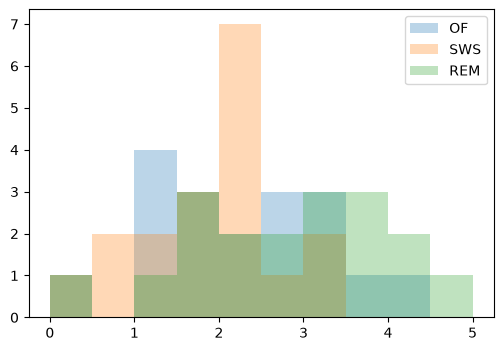

In [45]:
plt.figure(figsize = (6, 4))
plt.hist(mean_sspikes_OF[predictive_ids], bins = np.arange(0, 5.5, 0.5), alpha = 0.3, label = 'OF')
plt.hist(mean_sspikes_SWS[predictive_ids], bins = np.arange(0, 5.5, 0.5), alpha = 0.3, label = 'SWS')
plt.hist(mean_sspikes_REM[predictive_ids], bins = np.arange(0, 5.5, 0.5), alpha = 0.3, label = 'REM')
plt.legend()
plt.savefig(results_save_path + 'predictive_grid_cells_spike_rate_OF_vs_sleep.png')
plt.savefig(results_save_path + 'predictive_grid_cells_spike_rate_OF_vs_sleep.svg', format = 'svg')

pvalue_OF_SWS = scipy.stats.kstest(mean_sspikes_OF[predictive_ids], mean_sspikes_SWS[predictive_ids]).pvalue
pvalue_OF_REM = scipy.stats.kstest(mean_sspikes_OF[predictive_ids], mean_sspikes_SWS[predictive_ids]).pvalue
print('Predictive OF vs. SWS: ' + str(pvalue_OF_SWS))
print('Predictive OF vs. REM: ' + str(pvalue_OF_REM))


Non-predictive OF vs. SWS: 1.3274938399769663e-06
Non-predictive OF vs. REM: 1.3274938399769663e-06


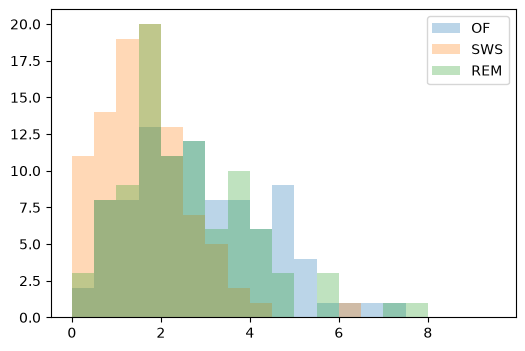

In [35]:
plt.figure(figsize = (6, 4))
plt.hist(mean_sspikes_OF[non_predictive_ids], bins = np.arange(0, 10, 0.5), alpha = 0.3, label = 'OF')
plt.hist(mean_sspikes_SWS[non_predictive_ids], bins = np.arange(0, 10, 0.5), alpha = 0.3, label = 'SWS')
plt.hist(mean_sspikes_REM[non_predictive_ids], bins = np.arange(0, 10, 0.5), alpha = 0.3, label = 'REM')
plt.legend()

pvalue_OF_SWS = scipy.stats.kstest(mean_sspikes_OF[non_predictive_ids], mean_sspikes_SWS[non_predictive_ids]).pvalue
pvalue_OF_REM = scipy.stats.kstest(mean_sspikes_OF[non_predictive_ids], mean_sspikes_SWS[non_predictive_ids]).pvalue
print('Non-predictive OF vs. SWS: ' + str(pvalue_OF_SWS))
print('Non-predictive OF vs. REM: ' + str(pvalue_OF_REM))

Predictive vs. non-predictive OF: 0.3221853163056574


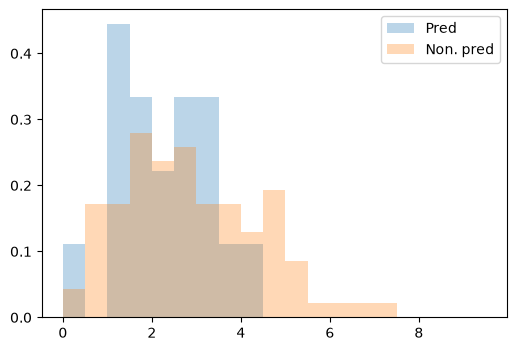

In [46]:
plt.figure(figsize = (6, 4))
plt.hist(mean_sspikes_OF[predictive_ids], bins = np.arange(0, 10, 0.5), density = 'True', alpha = 0.3, label = 'Pred')
plt.hist(mean_sspikes_OF[non_predictive_ids], bins = np.arange(0, 10, 0.5), density = 'True', alpha = 0.3, label = 'Non. pred')
plt.legend()
plt.savefig(results_save_path + 'predictive_grid_cells_vs_non_predictive_grid_cells_spike_rate_OF.png')
plt.savefig(results_save_path + 'predictive_grid_cells_vs_non_predictive_grid_cells_spike_rate_OF.svg', format = 'svg')

pvalue_OF_pred_non_pred = scipy.stats.kstest(mean_sspikes_OF[predictive_ids], mean_sspikes_OF[non_predictive_ids]).pvalue
print('Predictive vs. non-predictive OF: ' + str(pvalue_OF_pred_non_pred))

Predictive vs. non-predictive SWS: 0.10706043969652301


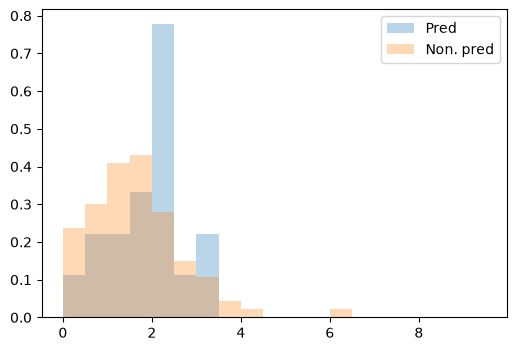

In [47]:
plt.figure(figsize = (6, 4))
plt.hist(mean_sspikes_SWS[predictive_ids], bins = np.arange(0, 10, 0.5), density = 'True', alpha = 0.3, label = 'Pred')
plt.hist(mean_sspikes_SWS[non_predictive_ids], bins = np.arange(0, 10, 0.5), density = 'True', alpha = 0.3, label = 'Non. pred')
plt.legend()
plt.savefig(results_save_path + 'predictive_grid_cells_vs_non_predictive_grid_cells_spike_rate_SWS.png')
plt.savefig(results_save_path + 'predictive_grid_cells_vs_non_predictive_grid_cells_spike_rate_SWS.svg', format = 'svg')

pvalue_SWS_pred_non_pred = scipy.stats.kstest(mean_sspikes_SWS[predictive_ids], mean_sspikes_SWS[non_predictive_ids]).pvalue
print('Predictive vs. non-predictive SWS: ' + str(pvalue_SWS_pred_non_pred))

Predictive vs. non-predictive REM: 0.4462915480019538


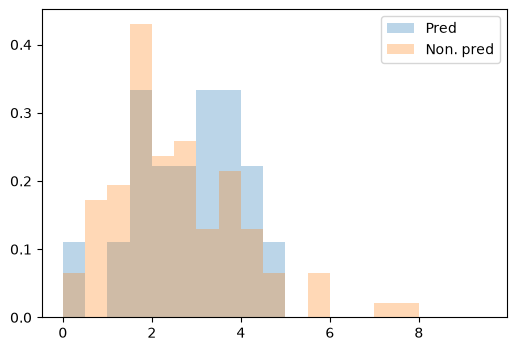

In [48]:
plt.figure(figsize = (6, 4))
plt.hist(mean_sspikes_REM[predictive_ids], bins = np.arange(0, 10, 0.5), density = 'True', alpha = 0.3, label = 'Pred')
plt.hist(mean_sspikes_REM[non_predictive_ids], bins = np.arange(0, 10, 0.5), density = 'True', alpha = 0.3, label = 'Non. pred')
plt.legend()
plt.savefig(results_save_path + 'predictive_grid_cells_vs_non_predictive_grid_cells_spike_rate_REM.png')
plt.savefig(results_save_path + 'predictive_grid_cells_vs_non_predictive_grid_cells_spike_rate_REM.svg', format = 'svg')

pvalue_REM_pred_non_pred = scipy.stats.kstest(mean_sspikes_REM[predictive_ids], mean_sspikes_REM[non_predictive_ids]).pvalue
print('Predictive vs. non-predictive REM: ' + str(pvalue_REM_pred_non_pred))